In [1]:
import pandas as pd
import numpy as np
import re, os
from pathlib import Path

In [ ]:
DATASET = Path('dataset')

files = {
    'bathroom':    'bathroom_dataset.csv',
    'bedroom':     'bedroom_dataset.csv',
    'home-office': 'home_office_dataset.csv',
    'kitchen':     'kitchen_dataset.csv',
    'living-room': 'living_room_dataset.csv',
    'pool':        'pool-ideas_dataset.csv',
}

dfs = {}
for room, fname in files.items():
    dfs[room] = pd.read_csv(DATASET / fname)

# fix pool labeling bug   →  pool file has room_type='dining-room' by mistake , 
# we trust the filename instead

In [3]:
for room, d in dfs.items():
    d['room_type'] = room
print('pool labeling fixed')

pool labeling fixed


# combine all 6 files into one DataFrame   →  keep only what captioning needs

In [4]:
df = pd.concat(dfs.values(), ignore_index=True)
df = df[['local_path', 'description', 'room_type']].copy()

print(f'combined: {len(df):,} rows × {df.shape[1]} cols')
print(f'columns:  {df.columns.tolist()}')
df.head(3)

combined: 24,042 rows × 3 cols
columns:  ['local_path', 'description', 'room_type']


,local_path,description,room_type
0,images/bathroom/bathroom_00000.jpg,Bathroom - country white tile white floor bath...,bathroom
1,images/bathroom/bathroom_00001.jpg,We transformed a mid-terrace Victorian bathroo...,bathroom
2,images/bathroom/bathroom_00002.jpg,Inspiration for a transitional multicolored ti...,bathroom


# text cleaning   →  url removal , whitespace normalization , photographer credits

In [5]:
URL_RE      = re.compile(r'https?://\S+|www\.\S+')
PIPE_PREFIX = re.compile(r'^[^|\n]{1,80}\|[^|\n]{1,80}\|[^|\n]{1,80}\s*')
WHITESPACE  = re.compile(r'\s+')


def basic_clean(s):
    s = str(s)
    s = PIPE_PREFIX.sub('', s)
    s = URL_RE.sub('', s)
    s = WHITESPACE.sub(' ', s).strip()
    return s


df['description'] = df['description'].apply(basic_clean)
print(f'after basic cleaning: {len(df)} rows')

after basic cleaning: 24042 rows


# drop UI scraping garbage   →  rows starting with "All Filters" are sidebar text

In [6]:
before = len(df)
df = df[~df['description'].str.startswith('All Filters', na=False)].reset_index(drop=True)
print(f'dropped {before - len(df)} UI-dump rows. remaining: {len(df)}')

dropped 5021 UI-dump rows. remaining: 19021


# strip templates and non-visual metadata
#
# the issue : Houzz captions follow a templated structure with stuff that's NOT
#             visible in the photo (cities , designers , subjective styles).
#             this teaches the model to hallucinate "in Denver" or "transitional".
#
# what we strip :
#   * "example of" / "inspiration for" / "idea" / "photo of"
#   * "<Room> -" prefix
#   * "in <City>" segments
#   * size words (small , mid sized , large)
#   * style words (transitional , modern , farmhouse , etc.)
#   * photographer / designer credits anywhere

In [7]:
# 1. boilerplate intros   →  match anywhere , not just start
INTRO_RE = re.compile(
    r'\b(example\s+of\s+a?n?|inspiration\s+for\s+a?n?|idea\s+for\s+a?n?|photo\s+of\s+a?n?)\s*',
    flags=re.IGNORECASE
)

# 2. "<Room> -" prefix
ROOM_PREFIX_RE = re.compile(
    r'^\s*(bathroom|bedroom|kitchen|living\s*room|dining\s*room|home\s*office|study\s*room|pool)s?\s*[-:]\s*',
    flags=re.IGNORECASE
)

# 3. cities   →  case-sensitive (cities are capitalized)
CITY_RE = re.compile(
    r'\s+in\s+[A-Z][a-zA-Z\.]+(?:\s+[A-Z][a-zA-Z\.]+){0,3}(?:\s*,\s*[A-Z][a-zA-Z\.]+(?:\s+[A-Z][a-zA-Z\.]+){0,1})?(?=\s+with\b|\s+and\b|\s*[\.,;]|$)',
    flags=0
)
CITY_OTHER_RE = re.compile(r'\s+in\s+other\b', flags=re.IGNORECASE)

# 4. size words
SIZE_RE = re.compile(
    r'\b(small|mid[\s-]?sized|medium[\s-]?sized|large|huge)\b',
    flags=re.IGNORECASE
)

# 5. style words
STYLE_WORDS = [
    'transitional', 'traditional', 'contemporary', 'modern',
    'mid[\\s-]?century', 'farmhouse', 'industrial', 'scandinavian',
    'rustic', 'coastal', 'eclectic', 'southwestern', 'tropical',
    'craftsman', 'asian', 'victorian', 'mediterranean',
    'shabby chic', 'arts and crafts', 'mountain style', 'beach style',
    'classic', 'trendy', 'vintage', 'timeless', 'minimalist',
    'tuscan', 'spanish style'
]
STYLE_RE = re.compile(r'\b(?:' + '|'.join(STYLE_WORDS) + r')\b', flags=re.IGNORECASE)

# 6. trailing boilerplate after room name
TRAILING_BOILERPLATE = re.compile(
    r'\b(bathroom|bedroom|kitchen|living\s*room|dining\s*room|home\s*office|study\s*room|pool)\s+(design|remodel|idea|photo|inspiration)\b',
    flags=re.IGNORECASE
)

# 7. photographer / designer credits ANYWHERE
PHOTO_CREDITS = re.compile(
    r'(?:'
    r'(?:photo(?:graphy)?|photos?)\s+by\s+[A-Za-z][\w\.\-\']+(?:\s+[A-Za-z][\w\.\-\']+){0,4}'
    r'|'
    r'\b[A-Z][\w\.\-\']+(?:\s+[A-Z][\w\.\-\']+){0,3}\s+Photography\b'
    r'|'
    r'\b(?:photography|photographer)\b'
    r'|'
    r'©\s*\d{0,4}\s*[A-Za-z][\w\.\-\']+(?:\s+[A-Za-z][\w\.\-\']+){0,4}'
    r'|'
    r'\bby\s+designer\s+[A-Za-z][\w\.\-\']+(?:\s+[A-Za-z][\w\.\-\']+){0,3}'
    r')',
    flags=re.IGNORECASE
)


def strip_templates(s):
    s = str(s)
    s = PHOTO_CREDITS.sub('', s)
    s = ROOM_PREFIX_RE.sub('', s)
    s = INTRO_RE.sub('', s)
    s = CITY_RE.sub('', s)
    s = CITY_OTHER_RE.sub('', s)
    s = SIZE_RE.sub(' ', s)
    s = STYLE_RE.sub(' ', s)
    s = TRAILING_BOILERPLATE.sub(r'\1', s)

    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'^\s*[,;-]\s*', '', s)
    s = re.sub(r'\s+([.,;])', r'\1', s)
    return s


# example
ex = "Photography by Anthony Barcelo. Example of a transitional master bedroom design in Denver with white walls."
print('BEFORE:', ex)
print('AFTER :', strip_templates(ex))

BEFORE: Photography by Anthony Barcelo. Example of a transitional master bedroom design in Denver with white walls.
AFTER : a master bedroom with white walls.


# apply to all captions and add word count column

In [8]:
df['description'] = df['description'].apply(strip_templates)
df['wc'] = df['description'].str.split().str.len()

print(f'rows: {len(df):,}')
print(f'word count   →   median {df["wc"].median():.0f}, mean {df["wc"].mean():.1f}')

rows: 19,021
word count   →   median 23, mean 45.8


# remove duplicates
# - cross-class : same caption , different room types  →  delete all (label noise)
# - within-class : same caption , one room type  →  keep one

In [9]:
# cross-class duplicates
desc_to_rooms = df.groupby('description')['room_type'].nunique()
cross_class = desc_to_rooms[desc_to_rooms > 1].index

before = len(df)
df = df[~df['description'].isin(cross_class)].copy()
print(f'cross-class duplicates dropped: {before - len(df)}')

# within-class duplicates  →  keep first
before = len(df)
df = df.drop_duplicates(subset=['description'], keep='first').reset_index(drop=True)
print(f'within-class duplicates dropped: {before - len(df)}')

print(f'rows remaining: {len(df):,}')

cross-class duplicates dropped: 500
within-class duplicates dropped: 2955
rows remaining: 15,566


# length filter   →  keep captions between 5 and 80 words

In [10]:
MIN_W, MAX_W = 5, 80

before = len(df)
df = df[df['wc'].between(MIN_W, MAX_W)].reset_index(drop=True)
print(f'length filter ({MIN_W}-{MAX_W} words) dropped: {before - len(df)}')
print(f'rows remaining: {len(df):,}')

length filter (5-80 words) dropped: 1835
rows remaining: 13,731


# quality audit   →  make sure templates are actually gone

In [11]:
print('quality audit:')
photo = df['description'].str.contains(r'\bphotography\b|\bphotographer\b', regex=True, case=False, na=False).sum()
intro = df['description'].str.contains(r'\b(example\s+of\s+a|inspiration\s+for\s+a)\b', regex=True, case=False, na=False).sum()
style = df['description'].str.contains(r'\b(transitional|modern|traditional|contemporary)\b', regex=True, case=False, na=False).sum()

print(f'   photography mentions  : {photo}/{len(df)}  ({photo/len(df)*100:.1f}%)')
print(f'   "example of a / etc." : {intro}/{len(df)}  ({intro/len(df)*100:.1f}%)')
print(f'   style words           : {style}/{len(df)}  ({style/len(df)*100:.1f}%)')

print('\nclass balance:')
print(df['room_type'].value_counts())

print('\nrandom samples:')
for _, r in df.sample(5, random_state=0).iterrows():
    print(f'   [{r["room_type"]:12s}] {r["description"][:130]}')

quality audit:


/tmp/ipykernel_132752/1977665579.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  intro = df['description'].str.contains(r'\b(example\s+of\s+a|inspiration\s+for\s+a)\b', regex=True, case=False, na=False).sum()
/tmp/ipykernel_132752/1977665579.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  style = df['description'].str.contains(r'\b(transitional|modern|traditional|contemporary)\b', regex=True, case=False, na=False).sum()


   photography mentions  : 0/13731  (0.0%)
   "example of a / etc." : 0/13731  (0.0%)
   style words           : 0/13731  (0.0%)

class balance:
room_type
bathroom       2614
living-room    2614
kitchen        2437
home-office    2200
bedroom        2186
pool           1680
Name: count, dtype: int64

random samples:
   [pool        ] Hot tub - backyard tile and rectangular hot tub idea
   [kitchen     ] We created a home that reflected the architecture and design of the Texas Hill Country through the lens of the client's personal s
   [kitchen     ] elegant l-shaped ceramic tile eat-in kitchen with raised-panel cabinets, dark wood cabinets, an island, an undermount sink, solid 
   [bedroom     ] Light and airy with a mix of bright and soft tones livens up this tween girls room. Custom made cornice with custom black out shad
   [pool        ] This lagoon/freeform swimming pool with raised spa and LED lights, Florida has a real feel! It's lush landscaping with palm trees,


# visualize

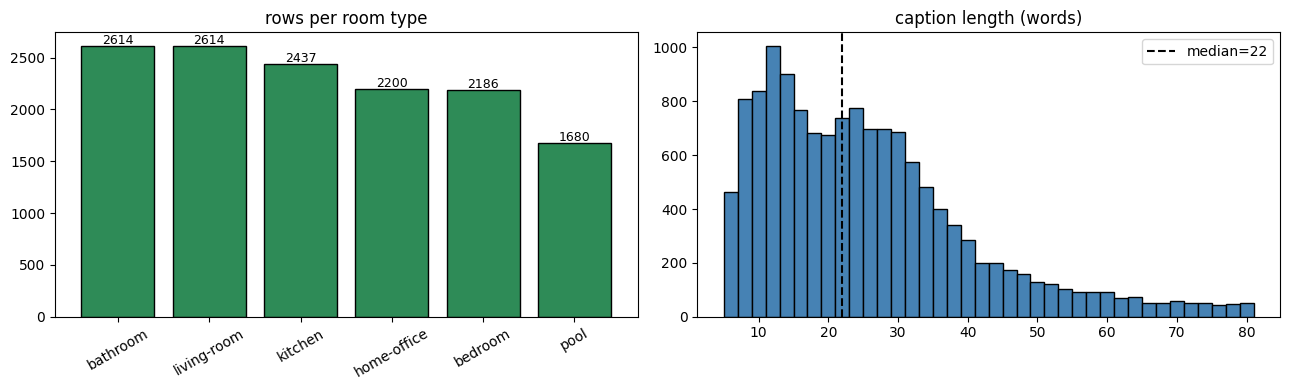

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['room_type'].value_counts()
axes[0].bar(counts.index, counts.values, color='seagreen', edgecolor='black')
axes[0].set_title('rows per room type')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

axes[1].hist(df['wc'], bins=range(5, 82, 2), color='steelblue', edgecolor='black')
axes[1].set_title('caption length (words)')
axes[1].axvline(df['wc'].median(), color='black', linestyle='--', label=f'median={df["wc"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# stratified train / val / test split (80 / 10 / 10)

In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['room_type'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['room_type'], random_state=42
)

print(f'train : {len(train_df):,}')
print(f'val   : {len(val_df):,}')
print(f'test  : {len(test_df):,}')

train : 10,984
val   : 1,373
test  : 1,374


# save   

In [14]:
df.to_csv('houzz_captioning.csv', index=False)
train_df.to_csv('train_caption.csv', index=False)
val_df.to_csv('val_caption.csv',     index=False)
test_df.to_csv('test_caption.csv',   index=False)

print('saved:')
for f in ['houzz_captioning.csv', 'train_caption.csv', 'val_caption.csv', 'test_caption.csv']:
    p = Path(f)
    print(f'  {f:25s}  {p.stat().st_size/1024:>8.1f} KB')

saved:
  houzz_captioning.csv         2848.0 KB
  train_caption.csv            2276.8 KB
  val_caption.csv               284.9 KB
  test_caption.csv              286.4 KB
